# Test preprocessing with `img.jpg`

This notebook loads `img.jpg`, extracts the character bounding box with OpenCV, and verifies the final 28×28 preprocessing output.

In [13]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import src.data.preprocessing as preprocessing
importlib.reload(preprocessing)
from src.data.preprocessing import extract_character_bbox, preprocess

# Update this if your image is in a different location
candidate_paths = [
    Path("img.jpg"),
    Path("../img.jpg"),
    Path("../data/raw/img.jpg"),
]

image_path = next((p for p in candidate_paths if p.exists()), None)
print("Resolved image path:", image_path if image_path else "NOT FOUND")

Resolved image path: ../data/raw/img.jpg


Extracted batch shape: (6395, 28, 28) dtype: uint8
Processed shape: (28, 28) range: (0.47843137383461, 0.5882353186607361)


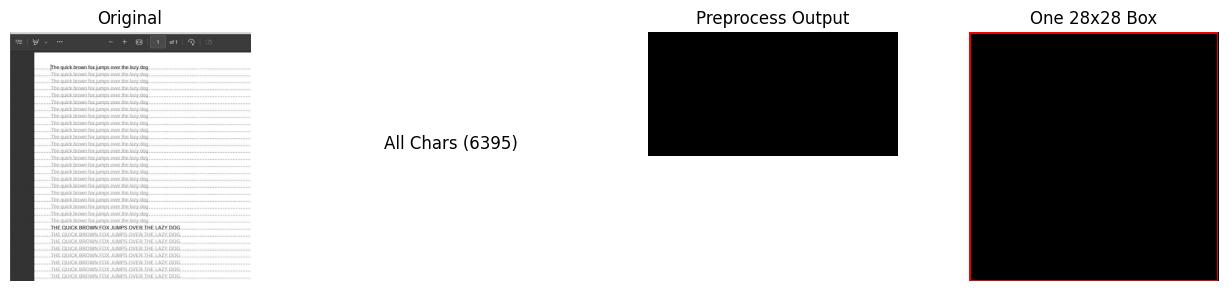

In [14]:
if image_path is None:
    print("Place img.jpg in notebooks/, project root, or data/user_samples/ and rerun.")
else:
    from matplotlib.patches import Rectangle

    original = Image.open(image_path)
    extracted = extract_character_bbox(original, target_size=28)
    processed_np = preprocess(original, target_size=28, return_type="numpy")

    # Support both old extractor output (28, 28) and new output (N, 28, 28)
    if extracted.ndim == 2:
        extracted_batch = extracted[np.newaxis, ...]
    else:
        extracted_batch = extracted

    print("Extracted batch shape:", extracted_batch.shape, "dtype:", extracted_batch.dtype)
    print("Processed shape:", processed_np.shape, "range:", (float(processed_np.min()), float(processed_np.max())))

    fig, axes = plt.subplots(1, 4, figsize=(13, 3))
    axes[0].imshow(original.convert("L"), cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    if extracted_batch.shape[0] > 0:
        preview = np.concatenate([char for char in extracted_batch], axis=1)
        axes[1].imshow(preview, cmap="gray")
        axes[1].set_title(f"All Chars ({extracted_batch.shape[0]})")
    else:
        axes[1].imshow(np.zeros((28, 28), dtype=np.uint8), cmap="gray")
        axes[1].set_title("All Chars (0)")
    axes[1].axis("off")

    axes[2].imshow(processed_np, cmap="gray")
    axes[2].set_title("Preprocess Output")
    axes[2].axis("off")

    axes[3].imshow(np.zeros((28, 28), dtype=np.uint8), cmap="gray", vmin=0, vmax=255)
    axes[3].add_patch(Rectangle((-0.5, -0.5), 28, 28, fill=False, edgecolor="red", linewidth=2))
    axes[3].set_title("One 28x28 Box")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()